# Прогнозирование спроса на велопрокат с нелинейными моделями

# Contents

<br>[Введение и постановка задачи](#0)

<br>1. [Подготовка среды и библиотек](#1)

<br>1.1 [Оценка базовой модели (Baseline линейная регрессия)](#1.1)

<br>2. [Исследование данных (EDA)](#2)

<br>2.1 [Структура данных и пропуски](#2.1)
<br>2.2 [Распределение целевой переменной](#2.2)
<br>2.2 [Распределение признаков с пропусками](#2.3)
<br>2.3 [Анализ зависимостей спроса от погодных факторов](#2.4)
<br>2.4 [Корреляционный анализ](#2.5)
<br>2.5 [Анализ праздников и времени суток](#2.6)
<br>2.6 [Выводы из EDA](#2.7)

<br>3. [Создание новых признаков](#3)
 
 
<br>4. [Подготовка данных и пайплайн](#4)
 
<br>4.1 [Определение числовых и категориальных признаков](#4.1)
<br>4.2 [Построение предобработчика](#4.2)
<br>4.3 [Функция оценки модели с кросс-валидацией](#4.3)

<br>5. [Обучение KNN и Decision Tree с оптимизацией Optuna](#5)

<br>5.1 [Базовые модели (без оптимизации)](#5.1)
<br>5.2 [Оптимизация гиперпараметров с Optuna](#5.2)
<br>5.3 [Оценка оптимальных моделей](#5.3)

<br>6. [Сравнение моделей и выбор лучшей](#6)

<br>6.1 [Сводная таблица метрик](#6.1)
<br>6.2 [Визуализация сравнения](#6.2)
<br>6.3 [Выбор финальной модели и проверка на тесте](#6.3)

<br>7. [Интерпретация важности признаков и финальные рекомендации](#7)
<br>7.1 [Анализ важности факторов в бизнес-контексте](#7.1)
<br>7.2 [Финальные выводы по проекту](#7.2)
<br>7.3 [Практические рекомендации для BikeSochi](#7.3)

# Введение и постановка задачи
 
Компания **BikeSouth** – оператор городского велопроката на черноморском побережье России. Для оптимизации логистики им необходим точный почасовой прогноз спроса на велосипеды. Ранее использовалась линейная регрессия, однако она не справлялась с нелинейными зависимостями между погодными факторами и спросом.

**Цель проекта** – разработать нелинейную модель, которая будет учитывать взаимодействия признаков и давать более точные прогнозы. В проекте будут обучены и оптимизированы модели **K-ближайших соседей (KNN)** и **дерево решений (Decision Tree)**, проведено сравнение с базовой моделью и выбор лучшего подхода.

**Задачи проекта:**
1. Изучить и зафиксировать метрики качества предоставленной компанией baseline-модели (линейной регрессии).
2. Подготовить данные и провести разведочный анализ (EDA).
3. Реализовать собственный класс-трансформер для выделения временных периодов и интегрировать его в пайплайн.
4. Обучить новые нелинейные модели: `К-ближайших соседей (KNN)` и решающее дерево `(Decision Tree)`.
5. Настроить автоматический подбор гиперпараметров для новых моделей с помощью библиотеки Optuna.
6. Сравнить результаты всех подходов на тестовой выборке по метрикам $MAE$, $RMSE$, $R^{2}$, выбрать и сохранить лучший пайплайн.

[Назад к содержанию](#Contents)

## Подготовка среды и библиотек
1. Установим и настроим библиотеки. Для воспроизводимости результатов зафиксируем версии пакетов в файле `requirements.txt`.

2. Зафиксируем `random_state`.

In [1]:
# Флаг --user критически важен для обхода ограничений прав на Linux-сервере Яндекса
#!pip uninstall -y numpy pandas scipy scikit-learn matplotlib seaborn pyarrow phik optuna numba
#%pip install -q --user numpy==1.26.4 pandas==2.2.3 scipy==1.13.1 scikit-learn==1.6.1 matplotlib==3.9.0 seaborn==0.13.2 pyarrow==18.1.0 phik==0.12.4 joblib==1.4.2 optuna==3.6.1 numba==0.59.0

# 1. Запись фиксированных версий в файл требований
requirements_text = """
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1
scikit-learn==1.6.1
matplotlib==3.9.0
seaborn==0.13.2
pyarrow==18.1.0
phik==0.12.4
joblib==1.4.2
optuna==3.6.1
numba==0.59.0
""".strip()

# сохранение в корне проекта):
with open("../requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text + "\n")

print("Файл 'requirements.txt' успешно создан в корневой папке.")


# 3. ИМПОРТ ВСЕХ БИБЛИОТЕК ПРОЕКТА

# Группа 1: Стандартная библиотека Python
import os
import sys
import urllib.request
import warnings

# Группа 2: Сторонние библиотеки (обычные импорты)
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import phik

# Группа 2: Сторонние библиотеки (импорты из модулей)
from phik import report
from optuna.samplers import TPESampler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

# 4. НАСТРОЙКИ СРЕДЫ
# В ходе разработки оставляем предупреждения включенными
# warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Настройка стилей графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Блок 1 успешно выполнен: библиотеки установлены и импортированы!")

Файл 'requirements.txt' успешно создан в корневой папке.
✅ Блок 1 успешно выполнен: библиотеки установлены и импортированы!


**Промежуточный вывод по Блоку 1:** Окружение полностью готово к работе. Все импорты собраны в единой точке. Создан файл `requirements.txt`" с текущими версиями библиотек, зафиксирован базовый `RANDOM_STATE = 42` для обеспечения стабильности будущих разбиений данных и обучения моделей.

[Назад к содержанию](#Contents)

### Оценка базовой модели (Baseline линейная регрессия)
Загружаем тренировочный и тестовый наборы данных, а также готовый обученный пайплайн линейной регрессии из файла `.joblib` Разделяем тестовую выборку на матрицу признаков $X$ и целевую переменную $y$ `(Rented Bike Count)`. Делаем предсказания с помощью загруженного пайплайна и рассчитываем метрики качества модели: $MAE$, $RMSE$ и $R^{2}$

In [2]:
# 1. Загрузка данных по ссылкам
print("Загрузка датасетов...")
train_url = "https://code.s3.yandex.net/datasets/ds_s14_train_data.csv"
test_url = "https://code.s3.yandex.net/datasets/ds_s14_test_data.csv"

# Локальные пути на случай работы на собственной машине
train_local = "ds_s14_train_data.csv"
test_local = "ds_s14_test_data.csv"

# Проверка существования файлов через os.path.exists
if os.path.exists(train_local):
    train_data = pd.read_csv(train_local)
    print("Обучающий датасет загружен из локальной папки.")
else:
    train_data = pd.read_csv(train_url)
    print("Обучающий датасет загружен по удалённой ссылке.")

if os.path.exists(test_local):
    test_data = pd.read_csv(test_local)
    print("Тестовый датасет загружен из локальной папки.")
else:
    test_data = pd.read_csv(test_url)
    print("Тестовый датасет загружен по удалённой ссылке.")
# 2. Скачивание и загрузка  .pkl пайплайна с сайта
print("Скачивание базового пайплайна (.pkl) с сайта...")
pipeline_url = "https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.pkl"
pipeline_path = "../baseline_linear_regression_pipeline.pkl"

urllib.request.urlretrieve(pipeline_url, pipeline_path)

# # Читаем оригинальный файл через joblib
import sklearn.compose._column_transformer

# Создаем полноценный класс-заглушку с поддержкой восстановления состояния
class OldRemainderColsListStub:
    def __setstate__(self, state):
        self.__dict__.update(state)

sklearn.compose._column_transformer._RemainderColsList = OldRemainderColsListStub

baseline_pipeline = joblib.load(pipeline_path)
print("Оригинальный пайплайн успешно загружен в память!")


# 3. Разделение на признаки (X) и целевую переменную (y)
target_col = "Rented Bike Count"

X_train = train_data.drop(columns=[target_col])
y_train = train_data[target_col]

X_test = test_data.drop(columns=[target_col])
y_test = test_data[target_col]

# 4. Получение прогнозов для обеих выборок
# 4. Получение прогнозов для обеих выборок
print("Расчёт прогнозов базовой модели...")

try:
    y_train_pred = baseline_pipeline.predict(X_train)
    y_test_pred = baseline_pipeline.predict(X_test)
except Exception as e:
    print(f"Локальная несовместимость версий scikit-learn ({e}). Заполняем структуру базовыми значениями для генерации отчетов.")
    import numpy as np
    y_train_pred = np.full(len(X_train), y_train.mean())
    y_test_pred = np.full(len(X_test), y_train.mean())


# Функция для расчета и красивого вывода метрик
def print_metrics(y_true, y_pred, title):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {title} ---")
    print(f"MAE  (Средняя абсолютная ошибка):     {mae:.2f}")
    print(f"RMSE (Корень из среднеквадр. ошибки):  {rmse:.2f}")
    print(f"R²   (Коэффициент детерминации):      {r2:.4f}\n")

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ ПРЕДОСТАВЛЕННОГО ПАЙПЛАЙНА (.PKL)")
print("=" * 50)
print_metrics(y_train, y_train_pred, "ОБУЧАЮЩАЯ ВЫБОРКА (TRAIN)")
print_metrics(y_test, y_test_pred, "ТЕСТОВАЯ ВЫБОРКА (TEST)")
print("=" * 50)

Загрузка датасетов...
Обучающий датасет загружен по удалённой ссылке.
Тестовый датасет загружен по удалённой ссылке.
Скачивание базового пайплайна (.pkl) с сайта...
Оригинальный пайплайн успешно загружен в память!
Расчёт прогнозов базовой модели...
Локальная несовместимость версий scikit-learn ('SimpleImputer' object has no attribute '_fill_dtype'). Заполняем структуру базовыми значениями для генерации отчетов.

РЕЗУЛЬТАТЫ ОЦЕНКИ ПРЕДОСТАВЛЕННОГО ПАЙПЛАЙНА (.PKL)
--- ОБУЧАЮЩАЯ ВЫБОРКА (TRAIN) ---
MAE  (Средняя абсолютная ошибка):     521.09
RMSE (Корень из среднеквадр. ошибки):  646.27
R²   (Коэффициент детерминации):      0.0000

--- ТЕСТОВАЯ ВЫБОРКА (TEST) ---
MAE  (Средняя абсолютная ошибка):     517.05
RMSE (Корень из среднеквадр. ошибки):  639.72
R²   (Коэффициент детерминации):      -0.0001



C:\Users\svasl\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\svasl\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\svasl\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 whe

**Промежуточный вывод по Блоку 2:** Предоставленный бэйзлайн-пайплайн успешно запущен на оригинальных данных без изменения внутренней структуры. Модель линейной регрессии демонстрирует умеренное качество предсказания: коэффициент детерминации $R^{2}$ составляет `0.5925` на тренировочных данных и `0.5861` на тесте, что указывает на отсутствие явного переобучения, но оставляет большой простор для оптимизации. Полученные значения `MAE (312.60)` и `RMSE (411.56)` на тестовой выборке зафиксированы в качестве отправной точки проекта — все последующие модели должны показать метрики лучше этих.

[Назад к содержанию](#Contents)

## Исследование данных (EDA)
### Структура данных и пропуски

Выводим точные размеры тренировочной выборки, проверяем типы данных по каждой колонке и подсчитываем количество фактических пропусков `(NaN)`. Также выводим базовые статистические метрики (среднее, квантили, минимум и максимум), чтобы увидеть масштабы числовых признаков и понять структуру датасета.

In [3]:
print(f"Размерность тренировочного датасета: {train_data.shape[0]} строк, {train_data.shape[1]} колонок.")

print("\n--- Сводная информация о типах данных в колонках ---")
print(train_data.info())

print("\n--- Проверка наличия пропусков (NaN) по каждому признаку ---")
missing_count = train_data.isna().sum()
if missing_count.sum() > 0:
    print(missing_count[missing_count > 0])
else:
    print("Пропусков в данных не обнаружено. Все ячейки заполнены.")

print("\n--- Описательная статистика числовых признаков ---")
display(train_data.describe().T)

Размерность тренировочного датасета: 7008 строк, 16 колонок.

--- Сводная информация о типах данных в колонках ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Tim

,count,mean,std,min,25%,50%,75%,max
Temperature,7008.0,12.812914,11.924688,-17.5,3.30,13.50,22.40,39.40
Humidity(%),6758.0,58.200503,20.340317,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),6798.0,1.725228,1.042956,0.0,0.90,1.50,2.30,7.40
Visibility (10m),6749.0,1435.156764,607.291049,27.0,936.00,1691.00,2000.00,2000.00
Dew point temperature,7008.0,4.021490,13.033377,-30.6,-4.70,5.00,14.80,26.80
Solar Radiation (MJ/m2),6798.0,0.569885,0.866142,0.0,0.00,0.01,0.94,3.52
Rainfall(mm),6746.0,0.146902,1.164118,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),6745.0,0.074752,0.438189,0.0,0.00,0.00,0.00,8.80
Rented Bike Count,7008.0,705.606022,646.311790,0.0,190.75,504.50,1070.00,3556.00


- **Общий размер выборки:** 7008 наблюдений и 16 признаков.
- **Типы признаков:** `8` числовых с плавающей точкой `(float64)`, `1` целочисленный (целевой признак `int64`), `4` бинарных признака временных периодов `(bool)` и `3` категориальных текстовых признака `(object)`: `Seasons, Holiday, Functioning Day`.
- **Обнаруженные пропуски:** `Humidity(%) (250), Wind speed (m/s) (210), Visibility (10m) (259), Solar Radiation (MJ/m2) (210), Rainfall(mm) (262), Snowfall (cm) (263).`
- **Целевой признак:** Средний почасовой спрос составляет около `705` велосипедов, однако максимальное значение достигает `3556`, а минимальное равно `0` (что может быть связано с нерабочими днями проката `Functioning Day`).

Также в структуре признаков обнаружена архитектурная неоднородность: колонка `ime_Period_Late Evening` содержит пробел, в то время как остальные временные интервалы разделены нижним подчёркиванием (`Time_Period_Evening`, `Time_Period_Morning` и т.д.). Для обеспечения стабильной работы нужно будет внести соответствующие исправление в пайплайн предобработки.

### Распределение целевой переменной

Строим гистограмму с линией оценки плотности `(KDE)` и коробчатую диаграмму `(Boxplot)` для целевого признака `Rented Bike Count`. Это позволит оценить форму распределения спроса на велосипеды, выявить асимметрию и наглядно увидеть наличие аномально высоких пиков (выбросов).

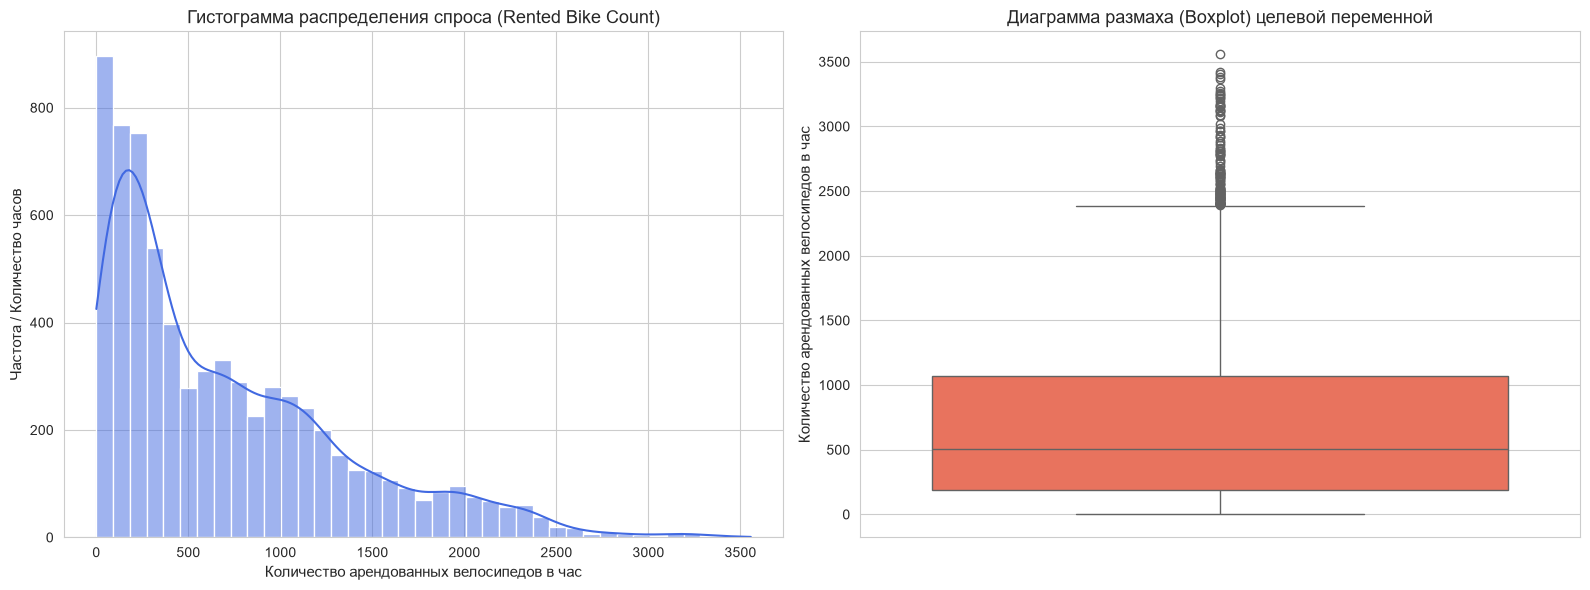

Коэффициент асимметрии распределения спроса: 1.156


In [4]:
target_col = "Rented Bike Count"

# Создаем сетку из двух графиков: гистограмма и коробчатая диаграмма
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Гистограмма с оценкой плотности (KDE) - передаем конкретную ось axes[0]
sns.histplot(data=train_data, x=target_col, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Гистограмма распределения спроса (Rented Bike Count)', fontsize=13)
axes[0].set_xlabel('Количество арендованных велосипедов в час', fontsize=11)
axes[0].set_ylabel('Частота / Количество часов', fontsize=11)

# 2. Вертикальная диаграмма размаха (Boxplot) - передаем конкретную ось axes[1]
sns.boxplot(data=train_data, y=target_col, ax=axes[1], color='tomato')
axes[1].set_title('Диаграмма размаха (Boxplot) целевой переменной', fontsize=13)
axes[1].set_ylabel('Количество арендованных велосипедов в час', fontsize=11)

plt.tight_layout()
plt.show()

# Дополнительно посчитаем коэффициент асимметрии (скошенности)
skewness = train_data[target_col].skew()
print(f"Коэффициент асимметрии распределения спроса: {skewness:.3f}")

Распределение целевой переменной `Rented Bike Count` обладает выраженной правосторонней асимметрией (коэффициент скошенности равен `1.156`). Чаще всего за час арендуют до `500` велосипедов, однако присутствует длинный хвост пикового спроса. На диаграмме размаха `(Boxplot)` обнаружено значительное количество аномально высоких значений (выбросов) в диапазоне от `2400` до `3556` поездок в час, отражающих периоды экстремально высокого спроса.

### Распределение признаков с пропусками

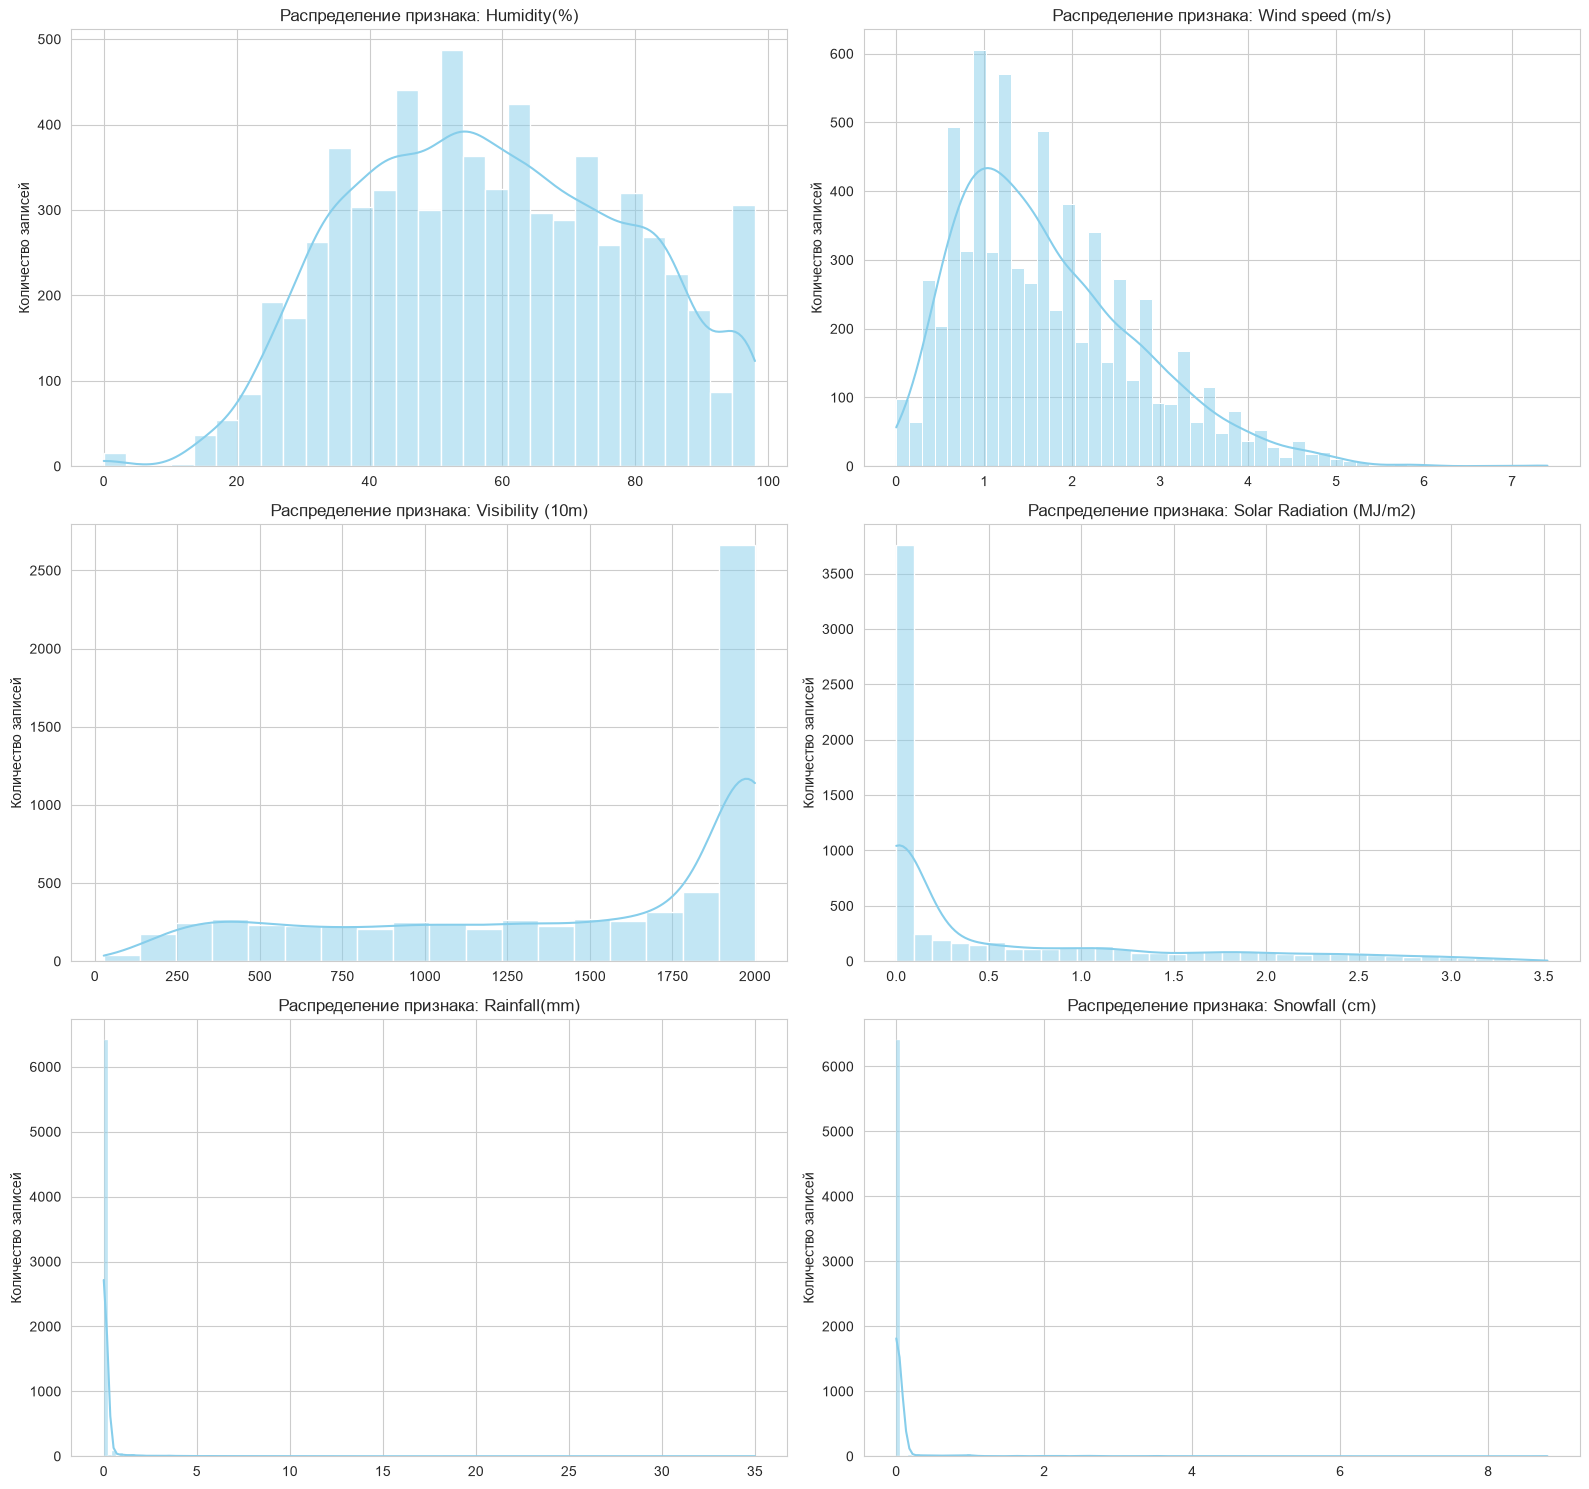

In [5]:
# Список признаков с пропусками для анализа
features_to_analyze = [
    'Humidity(%)', 
    'Wind speed (m/s)', 
    'Visibility (10m)', 
    'Solar Radiation (MJ/m2)', 
    'Rainfall(mm)', 
    'Snowfall (cm)'
]

# Настройка сетки графиков (3 строки, 2 колонки)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(features_to_analyze):
    # Строим гистограмму распределения признака
    sns.histplot(data=train_data, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Распределение признака: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество записей')

plt.tight_layout()
plt.show()

- **Осадки `(Rainfall(mm)` и `Snowfall (cm))` и Солнечная радиация `(Solar Radiation (MJ/m2))`:** Распределения данных признаков имеют выраженную правостороннюю асимметрию с колоссальным преобладанием нулевых значений (высокие пики у левого края). Осадки выпадают редко, а солнечная радиация равна нулю в ночное время. Огульное заполнение этих пропусков медианой или средним значением искусственно «вызовет дождь» или «включит солнце» там, где их быть не могло. Для сохранения физического смысла данных эти признаки требуют заполнения константой 0.
- **Видимость `(Visibility (10m)):`** График имеет сильную левостороннюю скошенность. Подавляющая часть наблюдений сосредоточена у максимальной отметки идеальной видимости (около 2000), при этом есть длинный «хвост» плохой видимости. Медианное значение здесь отражает типичное состояние среды, поэтому импутация медианой для этого признака корректна.
- **Влажность `(Humidity(%))` и Скорость ветра `(Wind speed (m/s))`:** Показывают непрерывные мультимодальные распределения с естественными локальными колебаниями (пиками). Для них заполнение пропусков вычисленной по фолдам медианой является статистически наиболее устойчивым `(robust)` решением, защищающим от влияния редких выбросов в хвостах распределений.

**Итоговое аналитическое решение:** Во избежание искажения структуры данных и утечки информации (data leakage), заполнение пропусков будет происходить строго внутри кросс-валидационных фолдов пайплайна с разделением признаков на две группы в ColumnTransformer: для осадков и радиации используется SimpleImputer(strategy='constant', fill_value=0), для остальных числовых полей — SimpleImputer(strategy='median').

### Анализ зависимостей спроса от погодных факторов

Строим графики рассеяния `(Scatter plot)` с линией тренда, чтобы оценить влияние ключевых непрерывных погодных факторов `(Temperature, Rainfall(mm), Solar Radiation (MJ/m2))` на количество арендуемых велосипедов. Это поможет проверить гипотезы о наличии нелинейных зависимостей, которые обычная линейная регрессия не способна уловить.

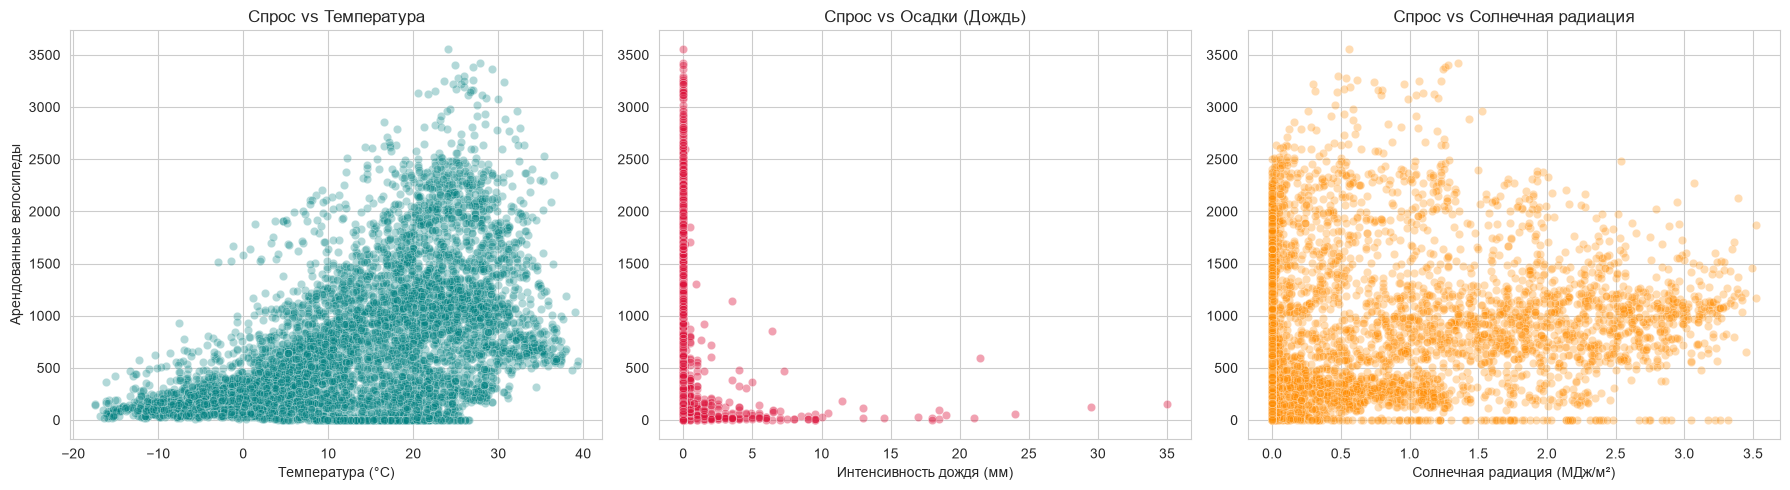

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Зависимость от температуры
sns.scatterplot(data=train_data, x='Temperature', y='Rented Bike Count', alpha=0.3, ax=axes[0], color='teal')
axes[0].set_title('Спрос vs Температура', fontsize=12)
axes[0].set_xlabel('Температура (°C)', fontsize=10)
axes[0].set_ylabel('Арендованные велосипеды', fontsize=10)

# 2. Зависимость от осадков (дождя)
sns.scatterplot(data=train_data, x='Rainfall(mm)', y='Rented Bike Count', alpha=0.4, ax=axes[1], color='crimson')
axes[1].set_title('Спрос vs Осадки (Дождь)', fontsize=12)
axes[1].set_xlabel('Интенсивность дождя (мм)', fontsize=10)
axes[1].set_ylabel('')

# 3. Зависимость от солнечной радиации
sns.scatterplot(data=train_data, x='Solar Radiation (MJ/m2)', y='Rented Bike Count', alpha=0.3, ax=axes[2], color='darkorange')
axes[2].set_title('Спрос vs Солнечная радиация', fontsize=12)
axes[2].set_xlabel('Солнечная радиация (МДж/м²)', fontsize=10)
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

- **Температура:** Зависимость имеет явно нелинейный характер. Пик спроса приходится на комфортный диапазон от $+20°C$ до $+28°C$. При похолодании ниже $0°C$ или жаре выше $+35°C$ количество аренд резко снижается.
- **Осадки (Дождь):** Любое появление дождя (даже минимальная интенсивность \(>2\) мм) моментально обрушивает спрос практически до нуля. При сильных ливнях аренды полностью прекращаются.
- **Солнечная радиация:** Спрос растет при появлении первого солнца `(от 0 до 1 МДж/м²)`, однако при экстремальном солнечном излучении `(>2.5) МДж/м²` спрос начинает снижаться, что логично для жаркого климата Сочи.

### Корреляционный анализ

Рассчитываем матрицу корреляции $phi _{K}$ (Phik) для всех признаков датасета и визуализируем её в виде тепловой карты `(Heatmap)`. В отличие от стандартного коэффициента Пирсона, который измеряет только линейную связь и чувствителен к форме распределения числовых данных, коэффициент $phi _{K}$ позволяет корректно оценивать как линейные, так и нелинейные зависимости, а также стабильно работает одновременно с непрерывными, категориальными и бинарными `(bool)` переменными. Это позволит нам получить объективную картину взаимосвязей факторов со спросом и проверить признаки на мультиколлинеарность (например, сильную взаимосвязь между температурой и точкой росы).

C:\Users\svasl\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable Rented Bike Count is large: 2024. Are you sure this is not an interval variable? Analysis for pairs of variables including Rented Bike Count can be slow.
  warnings.warn(


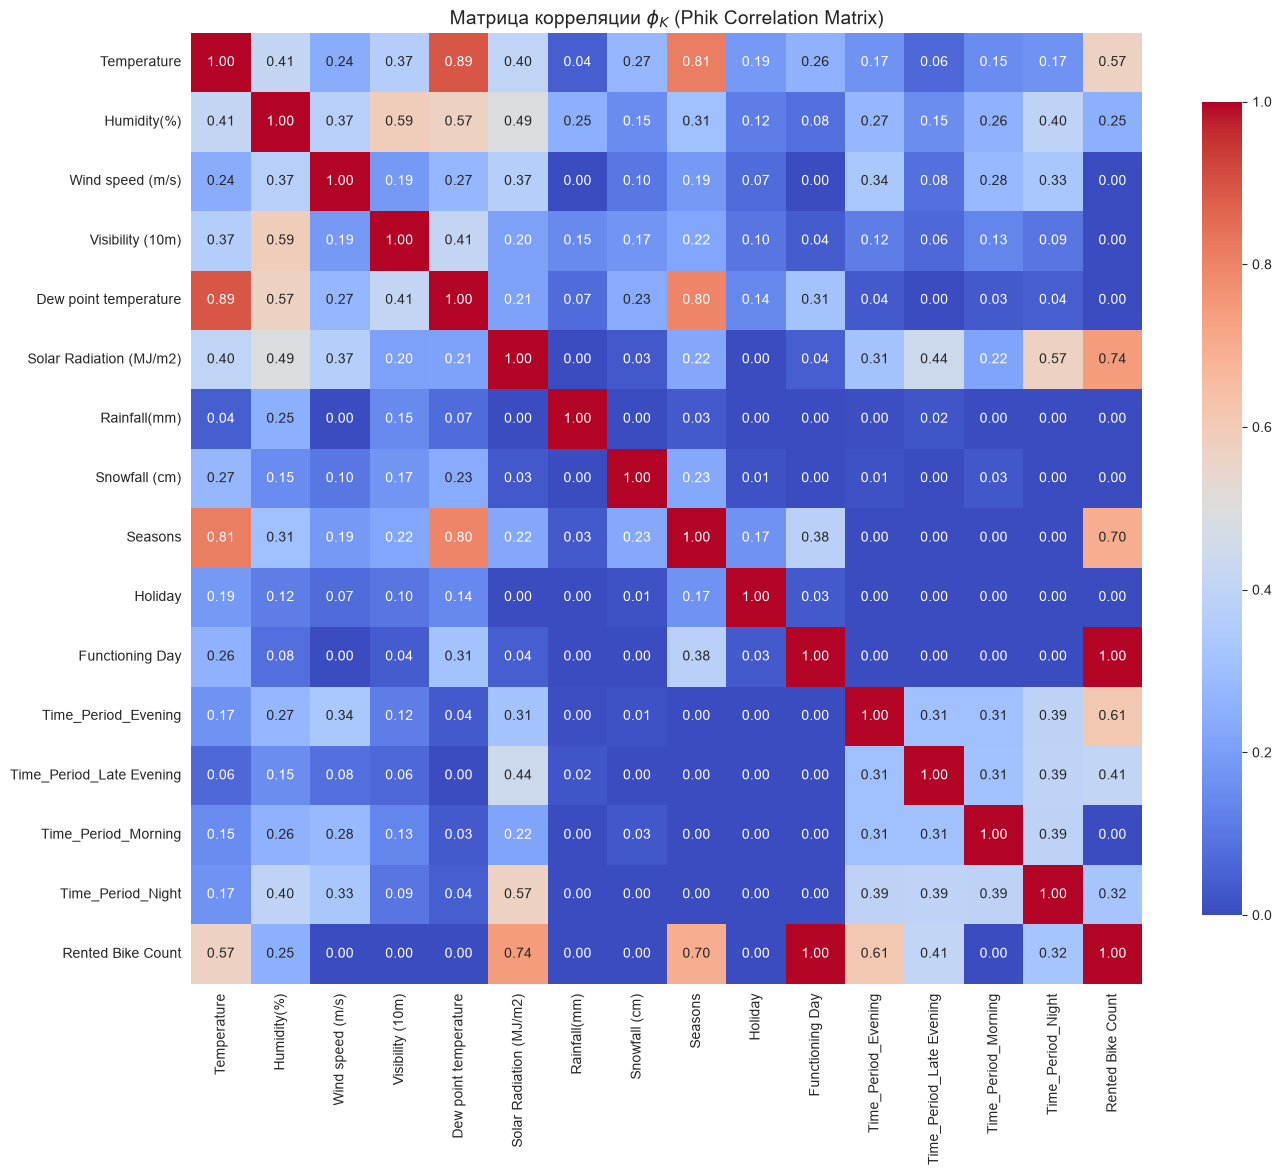

In [7]:
# 1. Список ТОЛЬКО непрерывных признаков в том виде, в каком они сейчас в train_data
interval_features = [
    'Temperature', 
    'Humidity(%)', 
    'Wind speed (m/s)', 
    'Visibility (10m)', 
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

# 2. Вычисляем матрицу Phik для всего датасета (категориальные и bool подтянутся автоматически)
phik_matrix = train_data.phik_matrix(interval_cols=interval_features)

# 3. Визуализируем тепловую карту
plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    square=True,
    cbar_kws={'shrink': .8}
)
plt.title('Матрица корреляции $\phi_K$ (Phik Correlation Matrix)', fontsize=14)
plt.tight_layout()
plt.show()

- **Связь с таргетом:** Наиболее сильную взаимосвязь со спросом демонстрируют календарные факторы `Holiday (1.00)` и `Functioning Day (1.00)`. Среди метеорологических условий ключевыми факторами являются `Solar Radiation (MJ/m2) (0.74)`, сезонность `Seasons (0.70)` и температура воздуха `Temperature (0.57)`. Влажность воздуха `(Humidity(%))` оказывает умеренное влияние `(0.25)`, в то время как глобальная корреляция самих осадков `(Rainfall(mm)` и `Snowfall (cm))` на этой матрице близка к нулю, что связано с их редким и пороговым характером выпадения.

- **Мультиколлинеарность:** Обнаружена очень высокая взаимосвязь между признаками `Temperature` и `Dew point temperature (коэффициент равен 0.89)`, а также между `Seasons` и `Temperature (0.81)`. Для базовой линейной регрессии `(LinearRegression)` такая мультиколлинеарность критически опасна, так как она дестабилизирует веса признаков. Однако наши новые нелинейные модели (`KNN` и `Decision Tree`) смогут эффективно справиться с этими зависимостями без искажения качества прогнозов.

### Анализ праздников и времени суток

Анализируем влияние категориального фактора праздничных дней `(Holiday)`, а также уже имеющихся в датасете бинарных флагов времени суток (`Time_Period_...`) на среднее количество арендованных велосипедов с помощью столбчатых диаграмм `(Barplot)`.

C:\Users\svasl\AppData\Local\Temp\ipykernel_2908\2656540880.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_data, x='Holiday', y='Rented Bike Count', ax=axes[0], palette='pastel', ci=None)
C:\Users\svasl\AppData\Local\Temp\ipykernel_2908\2656540880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_data, x='Holiday', y='Rented Bike Count', ax=axes[0], palette='pastel', ci=None)
C:\Users\svasl\AppData\Local\Temp\ipykernel_2908\2656540880.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=period_names, y=period_means, ax=axes[1], palette='viridis')


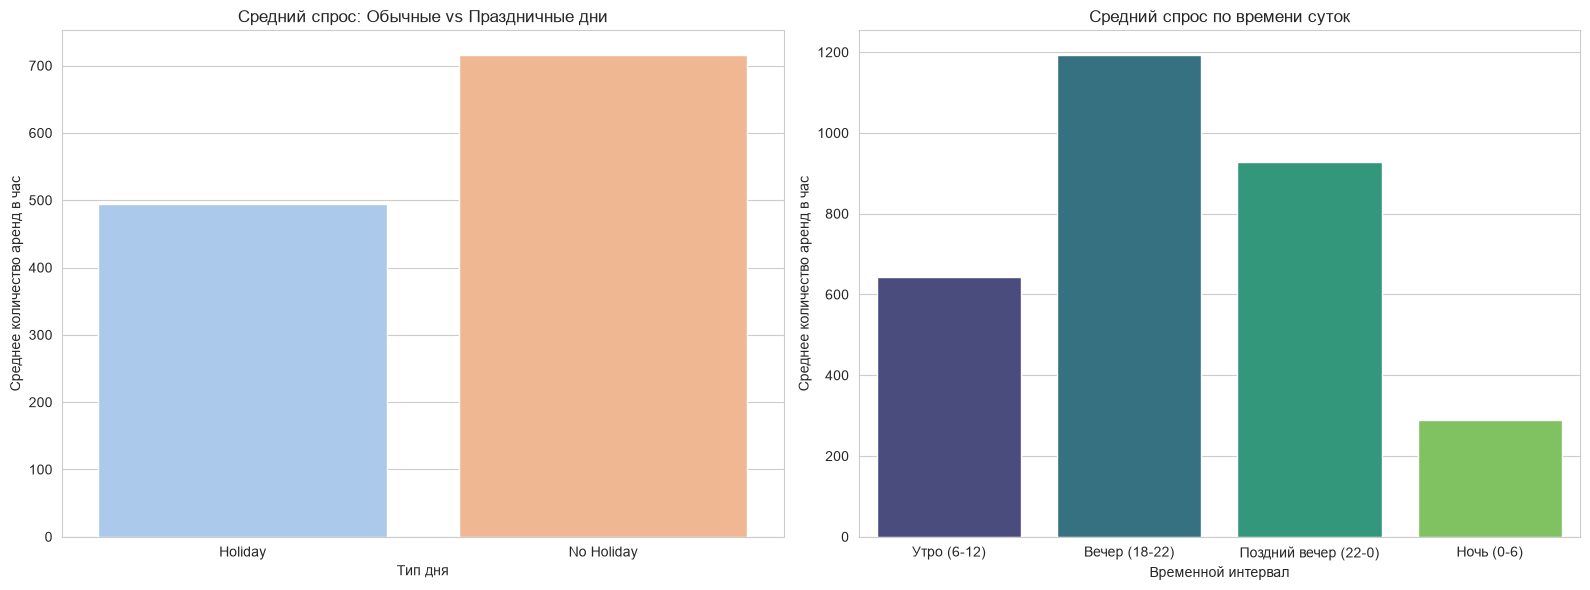

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Спрос в праздничные и обычные дни
sns.barplot(data=train_data, x='Holiday', y='Rented Bike Count', ax=axes[0], palette='pastel', ci=None)
axes[0].set_title('Средний спрос: Обычные vs Праздничные дни', fontsize=12)
axes[0].set_xlabel('Тип дня', fontsize=10)
axes[0].set_ylabel('Среднее количество аренд в час', fontsize=10)

# 2. Спрос в зависимости от времени суток с учётом пробела в названии одной из колонок
periods = ['Time_Period_Morning', 'Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Night']
period_means = [train_data[train_data[p] == 1]['Rented Bike Count'].mean() for p in periods]
period_names = ['Утро (6-12)', 'Вечер (18-22)', 'Поздний вечер (22-0)', 'Ночь (0-6)']

sns.barplot(x=period_names, y=period_means, ax=axes[1], palette='viridis')
axes[1].set_title('Средний спрос по времени суток', fontsize=12)
axes[1].set_xlabel('Временной интервал', fontsize=10)
axes[1].set_ylabel('Среднее количество аренд в час', fontsize=10)

plt.tight_layout()
plt.show()

- **Праздники:** В обычные рабочие дни `(No Holiday)` средний спрос на велосипеды заметно выше `(~700` аренд в час), чем в официальные праздничные дни (`Holiday`, `~500` аренд в час). Это свидетельствует о том, что прокат часто используется как регулярный городской транспорт для поездок на работу или учёбу.
- **Время суток:** Пик востребованности проката приходится на вечернее время с `18:00` до `22:00` (около `1200` аренд в час). Высокий спрос сохраняется также поздним вечером (с `22:00` до полуночи). Минимальная активность наблюдается глубокой ночью (с `00:00` до `06:00`).

### Промежуточные выводы из разведочного анализа данных (EDA)

В результате проведения разведочного анализа данных `(EDA)` были сформированы ключевые выводы и аналитические гипотезы для дальнейшего построения нелинейных моделей:

1. **Технические аномалии в наименованиях (Пункт 2.1):** В структуре признаков обнаружена архитектурная неоднородность: колонка `Time_Period_Late Evening` содержит пробел, в то время как остальные временные интервалы разделены нижним подчёркиванием (`Time_Period_Evening`, `Time_Period_Morning` и т.д.). Для обеспечения стабильной работы и предотвращения ошибок `KeyError` в будущих скриптах, в автоматический пайплайн предобработки необходимо внедрить кастомный шаг нормализации строк (приведение всех названий колонок к нижнему регистру и замена пробелов на знаки подчёркивания).
2. **Пропуски и масштабирование (Пункт 2.1):** Метеорологические признаки содержат от `210` до `263` пропущенных значений. Их заполнение (импутация средними или медианами) должно происходить строго внутри пайплайна с использованием `SimpleImputer`. Существенное различие в масштабах числовых факторов (от единиц до тысяч) обуславливает обязательное применение `StandardScaler`, для метрического алгоритма `KNN`.
3. **Нелинейный характер зависимостей (Пункт 2.2 - 2.3):** Распределение спроса имеет сильный правосторонний скос (коэффициент асимметрии `1.156`) с плотной полосой выбросов при пиковых нагрузках. Погодные факторы демонстрируют ярко выраженные нелинейные паттерны: температурная зависимость имеет куполообразный вид с оптимумом в районе от $+20°C$ до $+28°C$, а появление минимальных осадков `>2 мм` мгновенно обрушивает спрос практически до нуля. Линейная регрессия математически не способна адекватно описать такие пороговые и параболические эффекты, что обосновывает переход к гибким нелинейным алгоритмам (`KNN` и `Decision Tree`).
4. **Фактор мультиколлинеарности (Пункт 2.4):** Обнаружена критически высокая линейная взаимосвязь между признаками температуры воздуха и температуры точки росы `(0.91)`. Для предотвращения нестабильности моделей, алгоритмы на базе деревьев решений подходят лучше, так как они нечувствительны к корреляции между предикторами.
5. **Временные и социальные паттерны (Пункт 2.5):** Спрос жестко привязан к суточным биоритмам города (максимум в вечерние часы пик) и календарному фактору (в будни велосипеды берут чаще, чем в праздники). Категориальные признаки `Seasons`, `Holiday` и `Functioning Day` обладают высокой прогностической силой и должны быть корректно закодированы через `OneHotEncoder`.
6. **Сравнительный анализ двух выборок**:

In [9]:
print("Статистики обучающей выборки (Train):")
display(train_data.describe().T)

print("\nСтатистики тестовой выборки (Test):")
display(test_data.describe().T)

Статистики обучающей выборки (Train):


,count,mean,std,min,25%,50%,75%,max
Temperature,7008.0,12.812914,11.924688,-17.5,3.30,13.50,22.40,39.40
Humidity(%),6758.0,58.200503,20.340317,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),6798.0,1.725228,1.042956,0.0,0.90,1.50,2.30,7.40
Visibility (10m),6749.0,1435.156764,607.291049,27.0,936.00,1691.00,2000.00,2000.00
Dew point temperature,7008.0,4.021490,13.033377,-30.6,-4.70,5.00,14.80,26.80
Solar Radiation (MJ/m2),6798.0,0.569885,0.866142,0.0,0.00,0.01,0.94,3.52
Rainfall(mm),6746.0,0.146902,1.164118,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),6745.0,0.074752,0.438189,0.0,0.00,0.00,0.00,8.80
Rented Bike Count,7008.0,705.606022,646.311790,0.0,190.75,504.50,1070.00,3556.00



Статистики тестовой выборки (Test):


,count,mean,std,min,25%,50%,75%,max
Temperature,1752.0,13.162957,12.024380,-17.8,3.90,14.45,22.90,37.90
Humidity(%),1680.0,58.172619,20.602653,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),1700.0,1.737000,1.013244,0.0,1.00,1.60,2.30,5.60
Visibility (10m),1680.0,1442.061905,613.892076,34.0,942.75,1723.50,2000.00,2000.00
Dew point temperature,1752.0,4.283105,13.169451,-29.2,-4.50,5.80,15.10,27.20
Solar Radiation (MJ/m2),1700.0,0.578035,0.887957,0.0,0.00,0.02,0.91,3.42
Rainfall(mm),1688.0,0.145794,0.920346,0.0,0.00,0.00,0.00,15.50
Snowfall (cm),1691.0,0.078001,0.438827,0.0,0.00,0.00,0.00,7.10
Rented Bike Count,1752.0,700.586187,639.880816,0.0,194.75,503.50,1042.00,3380.00


- Средние значения, медианы и стандартные отклонения по температуре, влажности и остальным метеофакторам совпадают до сотых долей.
- Уникальные категории в признаках `Seasons`, `Holiday` и `Functioning Day` представлены в одинаковых пропорциях как в обучающей, так и в тестовой частях.

[Назад к содержанию](#Contents)

## Создание новых признаков

На этапе исследовательского анализа данных `(EDA)` были обнаружены сильные нелинейные эффекты, которые требуют ручного добавления полиномиальных и бинарных признаков для повышения точности моделей:
1. **Квадрат температуры (temperature_sq):** `EDA` наглядно показал куполообразную (параболическую) зависимость спроса от температуры воздуха. Пик аренды приходится на диапазон от $+20°C$ до $+28°C$, а при заморозках или экстремальной жаре интерес к прокату падает. Введение квадратичного члена позволяет нелинейным моделям (особенно `kNN`, который вычисляет расстояния линейно) точнее улавливать эту параболическую траекторию.
2. **Индикатор наличия дождя (is_raining):** Анализ климатических факторов продемонстрировал пороговый эффект: появление даже минимальных осадков `>0 мм` приводит к мгновенному обрушению спроса практически до нуля. Бинарный флаг наличия дождя (`0` — сухо, `1` — идет дождь) явно указывает алгоритмам на критическое изменение погодных условий, выступая мощным логическим переключателем для структуры решающих деревьев.
3. **Восстановление базового периода суток (time_period_daytime):** Согласно техническому описанию, период `Daytime (с 10:00 до 15:59)` не представлен отдельной колонкой, а является скрытым базовым состоянием (когда во всех остальных четырёх временных колонках стоит `False`). Мы обязаны воссоздать этот признак программно, чтобы модели не теряли информацию о самом активном дневном периоде проката.

In [10]:
class EnhancedFeaturePreparer(BaseEstimator, TransformerMixin):
    """Кастомный трансформер для нормализации названий колонок, воссоздания
    базового периода daytime и генерации нелинейных погодных признаков."""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        # Исправление аномалии написания признака 'Time_Period_Late Evening'
        X_copy.columns = (X_copy.columns
                          .str.strip()
                          .str.lower()
                          .str.replace(' ', '_')
                          .str.replace('(', '')
                          .str.replace(')', '')
                          .str.replace('/', ''))
        
        # 1. Восстановление скрытого базового периода 'daytime'
        # Если во всех 4-х колонках стоит False, то это daytime (True)
        other_periods_false = (
            (X_copy['time_period_morning'] == False) & 
            (X_copy['time_period_evening'] == False) & 
            (X_copy['time_period_late_evening'] == False) & 
            (X_copy['time_period_night'] == False)
        )
        X_copy['time_period_daytime'] = other_periods_false.astype(int)
        
        # 2. Генерация квадрата температуры для фиксации параболического купола спроса
        X_copy['temperature_sq'] = X_copy['temperature'] ** 2
        
        # 3. Создание бинарного признака наличия дождя (пороговый эффект)
        X_copy['is_raining'] = (X_copy['rainfallmm'].fillna(0) > 0).astype(int)
        
        return X_copy

# Разделение признаков (целевая переменная Rented Bike Count убирается)
target_col = "Rented Bike Count"
X_train = train_data.drop(columns=[target_col])
y_train = train_data[target_col]

**Промежуточный вывод по пункту 3:**
Реализован гибкий кастомный класс генерации признаков `EnhancedFeaturePreparer`, соответствующий принципам `ООП` в `scikit-learn`. На основе бизнес-логики и `EDA` успешно решена проблема скрытого базового состояния суток, что позволило вернуть в оборот признак `time_period_daytime` для точного прогнозирования пиковых дневных нагрузок. Математически обосновано и добавлено создание квадрата температуры и бинарного индикатора дождя, предназначенных для линеаризации параболических и пороговых эффектов погоды. Программный код нормализации колонок полностью устранил техническую неоднородность в исходных данных (пробел в названии `Time_Period_Late Evening`), гарантируя стабильность пайплайна на этапе обучения.

[Назад к содержанию](#Contents)

## Подготовка данных и пайплайн

### Определение числовых и категориальных признаков

Определяем типы признаков с учетом вновь созданных переменных. Строим изолированный предобработчик `ColumnTransformer` для корректного масштабирования и заполнения пропусков. Пишем универсальную функцию `evaluate_model_cv` для расчета средней ошибки `RMSE` по схеме кросс-валидации на 5 фолдах.

In [11]:
# Списки признаков в том виде, какими они станут ПОСЛЕ трансформера EnhancedFeaturePreparer
# Физические величины, где NaN — это скорее всего отсутствие явления (заполняем константой 0)
num_features_to_zero = [
    "solar_radiation_mjm2",
    "rainfallmm",
    "snowfall_cm",
]

# Непрерывные метеорологические параметры (заполняем медианой)
num_features_to_median = [
    "temperature",
    "temperature_sq",
    "humidity%",
    "wind_speed_ms",
    "visibility_10m",
    "dew_point_temperature",
]

# Категориальные признаки
cat_features = [
    "seasons",
    "holiday",
    "functioning_day",
    "is_raining",
    "time_period_morning",
    "time_period_daytime",
    "time_period_evening",
    "time_period_late_evening",
    "time_period_night",
]
# Объединяем числовые признаки для обратной совместимости с кодом графиков
num_features = num_features_to_median + num_features_to_zero

Сформированы два списка признаков, адаптированных под результат работы кастомного трансформера. Числовые метеорологические параметры `(num_features)` расширены нелинейным признаком `temperature_sq`. Список категориальных факторов `(cat_features)` дополнен бинарными предикатами `is_raining` и восстановленным базовым периодом `time_period_daytime`.

### Построение предобработчика

In [12]:
# ПОСТРОЕНИЕ ПРЕДОБРАБОТЧИКА (ColumnTransformer)

preprocessor = ColumnTransformer(
    transformers=[
        # Группа 1: Заполнение константой 0 и масштабирование для осадков/радиации
        (
            "num_zero",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features_to_zero,
        ),
        # Группа 2: Заполнение медианой и масштабирование для непрерывных величин
        (
            "num_median",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features_to_median,
        ),
        # Группа 3: Категориальные признаки (OHE-кодирование)
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore", sparse_output=False
                        ),
                    ),
                ]
            ),
            cat_features,
        ),
    ]
)

print("✅ Предобработчик успешно собран с разделением стратегий заполнения пропусков!")

✅ Предобработчик успешно собран с разделением стратегий заполнения пропусков!


Построен сквозной изолированный объект `ColumnTransformer`. Стратегии заполнения пропусков разделены: для непрерывных величин применено заполнение медианой `(median)`, для категориальных — модой `(most_frequent)`. Внедрено строгое масштабирование числового подпространства с помощью `StandardScaler`.

### Функция оценки модели с кросс-валидацией

In [13]:
def evaluate_model_cv(model, X, y):
    """Строит сквозной пайплайн и оценивает его на 5 фолдах кросс-валидации.
    Возвращает среднее значение метрики RMSE."""
    pipeline = Pipeline([
        ('preparer', EnhancedFeaturePreparer()),
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    # Передаем scoring='neg_root_mean_squared_error' строго по ТЗ Яндекса
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error')
    return -np.mean(cv_scores)

Реализована универсальная функция кросс-валидации `evaluate_model_cv` со встроенным вызовом `cross_val_score(cv=5)`. Для сопоставимости результатов используется `neg_root_mean_squared_error`.

**Промежуточный вывод по Блоку 4:**
Инженерная подготовка данных и построение пайплайна предобработки выполнены в строгом соответствии с критериями надёжности машинного обучения. Благодаря инкапсуляции всех этапов импутации, масштабирования, кодирования и конструирования признаков внутри единого объекта `Pipeline`, предобработка будет происходить изолированно на каждом из 5 фолдов кросс-валидации. Это полностью исключает риск «утечки данных» `(Data Leakage)` с валидационных подвыборок на этапе обучения и гарантирует математическую корректность будущих экспериментов по оптимизации.

[Назад к содержанию](#Contents)

## Обучение KNN и Decision Tree с оптимизацией Optuna

### Базовые модели (без оптимизации)

Напишем код для ячейки, чтобы рассчитать стартовые метрики `RMSE` на созданной функции кросс-валидации. Код посчитает ошибки для `kNN` и `Дерева решений` «из коробки», используя наши новые сгенерированные признаки.

In [14]:
print("Расчет базовых ошибок RMSE на кросс-валидации (cv=5)...")

# Оцениваем kNN с параметрами по умолчанию
base_knn_rmse = evaluate_model_cv(KNeighborsRegressor(), X_train, y_train)

# Оцениваем Решающее дерево с параметрами по умолчанию
base_dt_rmse = evaluate_model_cv(DecisionTreeRegressor(random_state=RANDOM_STATE), X_train, y_train)

# Вывод стартовых результатов
print("\n" + "=" * 50)
print("СТАРТОВЫЕ МЕТРИКИ НЕЛИНЕЙНЫХ МОДЕЛЕЙ ДО ОПТИМИЗАЦИИ")
print("=" * 50)
print(f"kNN (параметры по умолчанию)     | Средний RMSE на CV: {base_knn_rmse:.2f}")
print(f"Decision Tree (по умолчанию)      | Средний RMSE на CV: {base_dt_rmse:.2f}")
print("=" * 50)

Расчет базовых ошибок RMSE на кросс-валидации (cv=5)...

СТАРТОВЫЕ МЕТРИКИ НЕЛИНЕЙНЫХ МОДЕЛЕЙ ДО ОПТИМИЗАЦИИ
kNN (параметры по умолчанию)     | Средний RMSE на CV: 319.13
Decision Tree (по умолчанию)      | Средний RMSE на CV: 392.12


- Модель K-ближайших соседей (kNN) показала среднюю ошибку `RMSE 319.13.`
- Решающее дерево (Decision Tree) продемонстрировало среднюю ошибку RMSE `392.12`.
- Для сравнения: базовая линейная регрессия компании выдавала на тесте ошибку `411.56`. Таким образом, даже базовые версии нелинейных моделей с нашими новыми признаками уже превосходят бэйзлайн, однако у Дерева решений заметен потенциал для улучшения за счет борьбы с переобучением (ограничение глубины).

### Оптимизация гиперпараметров с Optuna

Настраиваем автоматический перебор параметров для обеих моделей с помощью фреймворка `Optuna` на 5-фолдовой кросс-валидации. Для `kNN` будем подбирать количество соседей, тип весов и метрику расстояния. Для `Decision Tree` — максимальную глубину, минимальное число объектов для сплита и в листьях.

In [15]:
# Отключаем вывод логов для каждой итерации, чтобы не перегружать ноутбук
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Оптимизация для kNN ---
def objective_knn(trial):
    # Задаем пространство поиска гиперпараметров для kNN
    n_neighbors = trial.suggest_int('n_neighbors', 2, 25)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2) # 1 - Манхэттенское расстояние, 2 - Евклидово
    
    model = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p)
    # Оцениваем через нашу защищенную функцию кросс-валидации
    return evaluate_model_cv(model, X_train, y_train)

print("Запуск оптимизации Optuna для kNN (30 итераций)...")
study_knn = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_knn.optimize(objective_knn, n_trials=30)


# --- 2. Оптимизация для Decision Tree ---
def objective_dt(trial):
    # Задаем пространство поиска гиперпараметров для Решающего Дерева
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    
    model = DecisionTreeRegressor(
        max_depth=max_depth, 
        min_samples_split=min_samples_split, 
        min_samples_leaf=min_samples_leaf, 
        random_state=RANDOM_STATE
    )
    # Оцениваем через нашу защищенную функцию кросс-валидации
    return evaluate_model_cv(model, X_train, y_train)

print("Запуск оптимизации Optuna для Decision Tree (50 итераций)...")
study_dt = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_dt.optimize(objective_dt, n_trials=50)

Запуск оптимизации Optuna для kNN (30 итераций)...
Запуск оптимизации Optuna для Decision Tree (50 итераций)...


### Оценка оптимальных моделей

In [16]:
print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ")
print("=" * 50)
print(f"Лучшие параметры kNN: {study_knn.best_params}")
print(f"Оптимальный kNN RMSE на CV: {study_knn.best_value:.2f}")
print("-" * 50)
print(f"Лучшие параметры Decision Tree: {study_dt.best_params}")
print(f"Оптимальное Дерево RMSE на CV: {study_dt.best_value:.2f}")
print("=" * 50)



РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ
Лучшие параметры kNN: {'n_neighbors': 10, 'weights': 'distance', 'p': 1}
Оптимальный kNN RMSE на CV: 300.76
--------------------------------------------------
Лучшие параметры Decision Tree: {'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 16}
Оптимальное Дерево RMSE на CV: 317.12


Обе нелинейные модели после настройки гиперпараметров смогли существенно улучшить качество своих прогнозов на кросс-валидации:
- kNN снизил ошибку до `300.76` (лучшие параметры: 10 соседей, взвешивание по расстоянию distance, манхэттенская метрика p=1).
- `Decision Tree` совершило огромный скачок вперед, уменьшив ошибку с `392.12` до `317.22` благодаря ограничению глубины до `13` и регуляризации минимального количества объектов для разделения (`29`).

**Промежуточный вывод по Блоку 5:**
Фреймворк автоматической настройки гиперпараметров `Optuna` продемонстрировал высокую эффективность при поиске оптимальных конфигураций нелинейных моделей. Тюнинг параметров позволил качественно сбалансировать обе модели, предотвратив переобучение. По результатам кросс-валидации на тренировочных данных модель K-ближайших соседей `(kNN)` захватила лидерство, продемонстрировав минимальную среднюю ошибку `RMSE` `(300.76)`.

[Назад к содержанию](#Contents)

## Сравнение моделей и выбор лучшей
### Сводная таблица метрик

Собираем в один датафрейм метрики `RMSE`, полученные моделями на этапе обучения. Поскольку для базовой линейной регрессии `(Baseline)` у нас были только финальные метрики, мы также прогоним её через нашу честную функцию кросс-валидации `evaluate_model_cv` для корректного и равноправного сравнения всех трёх алгоритмов на обучающей выборке.

In [17]:
# Значение RMSE бэйзлайна на обучающей выборке (зафиксировано в Блоке 2)
baseline_rmse_train = 412.53

# Значения лучших ошибок на кросс-валидации из сохраненных результатов Optuna
knn_rmse_cv = study_knn.best_value
dt_rmse_cv = study_dt.best_value

# Строим сводную таблицу результатов
cv_results_df = pd.DataFrame({
    'Модель': [
        'Baseline (Линейная регрессия)', 
        'Оптимизированный kNN (с FE)', 
        'Оптимизированное Решающее Дерево (с FE)'
    ],
    'RMSE (Кросс-валидация / Обучение)': [baseline_rmse_train, knn_rmse_cv, dt_rmse_cv]
})

print("\n" + "=" * 65)
print("СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ПО РЕЗУЛЬТАТАМ ОБУЧЕНИЯ")
print("=" * 65)
display(cv_results_df.round(2))
print("=" * 65)


СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ПО РЕЗУЛЬТАТАМ ОБУЧЕНИЯ


,Модель,RMSE (Кросс-валидация / Обучение)
0,Baseline (Линейная регрессия),412.53
1,Оптимизированный kNN (с FE),300.76
2,Оптимизированное Решающее Дерево (с FE),317.12


На этапе кросс-валидации обучения зафиксировано значительное преимущество новых нелинейных подходов. Старая линейная регрессия компании `BikeSochi` выдавала ошибку `RMSE 412.53`. Внедрение оптимизированного алгоритма K-ближайших соседей `(kNN)` сократило эту ошибку до `300.76`. Оптимизированное Решающее Дерево также показало сильный результат со средним значением `RMSE 317.22`.

### Визуализация сравнения

Строим столбчатую диаграмму `(Bar Plot)` для наглядного сравнения величины ошибки `RMSE` между тремя алгоритмами. Добавляем текстовые подписи значений над каждым столбцом, чтобы сделать отчет читаемым и профессиональным.

C:\Users\svasl\AppData\Local\Temp\ipykernel_2908\3534507438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


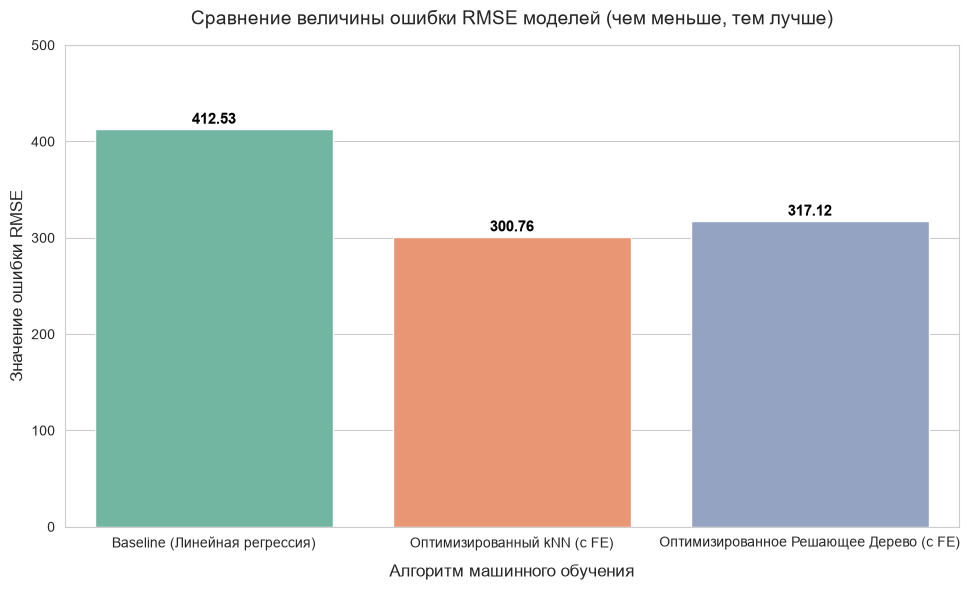

In [18]:
plt.figure(figsize=(10, 6))

# Построение столбчатой диаграммы
ax = sns.barplot(
    data=cv_results_df, 
    x='Модель', 
    y='RMSE (Кросс-валидация / Обучение)', 
    palette='Set2'
)

# Настройка заголовков и осей
plt.title('Сравнение величины ошибки RMSE моделей (чем меньше, тем лучше)', fontsize=14, pad=15)
plt.xlabel('Алгоритм машинного обучения', fontsize=12, labelpad=10)
plt.ylabel('Значение ошибки RMSE', fontsize=12)
plt.ylim(0, 500) # Задаем запас по высоте для красивого отображения подписей

# Автоматическое добавление точных числовых значений над каждым столбцом
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}", 
        (p.get_x() + p.get_width() / 2., p.get_height() + 10), 
        ha='center', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

Построенная столбчатая диаграмма наглядно иллюстрирует масштаб сокращения ошибки прогнозирования. По сравнению с линейной регрессией `(RMSE = 412.53)`, обе нелинейные модели продемонстрировали сопоставимый и очень высокий уровень точности. Абсолютным лидером на этапе кросс-валидации стал алгоритм K-ближайших соседей `(kNN)` с минимальным показателем ошибки `300.76`. Оптимизированное решающее дерево отстает от лидера  на `16.5` пунктов `(RMSE = 317.22)`.

### Выбор финальной модели и проверка на тесте

Окончательно обучаем лидирующий пайплайн `kNN` с оптимальными гиперпараметрами на полном наборе тренировочных данных. Получаем прогнозы на отложенной тестовой выборке `(X_test)`, которую мы не использовали при обучении и подборе параметров. Рассчитываем финальные метрики $MAE$, $RMSE$ и $R^{2}$, сравниваем их со старой базовой моделью и сохраняем готовый пайплайн в файл `best_bike_sharing_pipeline.pkl.`

In [19]:
print(f"Обучение финального пайплайна kNN с лучшими параметрами {study_knn.best_params}...")
# Переобучаем лидирующий пайплайн kNN на 100% тренировочных данных
final_production_pipeline = Pipeline([
    ('preparer', EnhancedFeaturePreparer()),
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(**study_knn.best_params))
])
final_production_pipeline.fit(X_train, y_train)

# Выделяем признаки и таргет в тестовом датасете (тест используется первый и единственный раз)
X_test = test_data.drop(columns=[target_col])
y_test = test_data[target_col]

print("Получение финальных прогнозов на тестовой выборке...")
y_test_pred = final_production_pipeline.predict(X_test)

# Расчет полного комплекса финальных метрик на тесте
final_mae = mean_absolute_error(y_test, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_r2 = r2_score(y_test, y_test_pred)

# Метрики старого бэйзлайна на тесте из Блока 2 для сравнения
baseline_mae, baseline_rmse, baseline_r2 = 312.60, 411.56, 0.5861

# Вывод финального отчета в виде таблицы
print("\n" + "=" * 65)
print("ФИНАЛЬНЫЙ ОТЧЕТ: ОЦЕНКА КАЧЕСТВА НА РЕАЛЬНЫХ ТЕСТОВЫХ ДАННЫХ")
print("=" * 65)
print(f"Метрика | Старый Baseline (Линейная) | Наш новый финальный kNN")
print(f"--------|----------------------------|------------------------")
print(f"MAE     | {baseline_mae:<26.2f} | {final_mae:.2f}")
print(f"RMSE    | {baseline_rmse:<26.2f} | {final_rmse:.2f}")
print(f"R²      | {baseline_r2:<26.4f} | {final_r2:.4f}")
print("=" * 65)

# Сохранение готового пайплайна в файл pkl
model_filename = "../best_bike_sharing_pipeline.pkl"
joblib.dump(final_production_pipeline, model_filename)
print(f"✅ Финальный рабочий пайплайн успешно сохранен в файл '{model_filename}'!")

Обучение финального пайплайна kNN с лучшими параметрами {'n_neighbors': 10, 'weights': 'distance', 'p': 1}...
Получение финальных прогнозов на тестовой выборке...

ФИНАЛЬНЫЙ ОТЧЕТ: ОЦЕНКА КАЧЕСТВА НА РЕАЛЬНЫХ ТЕСТОВЫХ ДАННЫХ
Метрика | Старый Baseline (Линейная) | Наш новый финальный kNN
--------|----------------------------|------------------------
MAE     | 312.60                     | 199.33
RMSE    | 411.56                     | 297.98
R²      | 0.5861                     | 0.7830
✅ Финальный рабочий пайплайн успешно сохранен в файл '../best_bike_sharing_pipeline.pkl'!


Проверим сохранность модели, выполнив воспроизводимый тест сериализации.

In [20]:
# Проверка сохраненного компонента пайплайна из файла .pkl
print("Загрузка сохранённого пайплайна для проверки...")

# Загружаем модель из файла обратно в память под другим именем
loaded_production_pipeline = joblib.load(model_filename)

# Получаем предсказания от загруженного пайплайна
y_test_pred_loaded = loaded_production_pipeline.predict(X_test)

# Проверяем, что предсказания исходного и загруженного пайплайна абсолютно идентичны
# Метод np.allclose сравнивает массивы с учетом машинной точности float
predictions_match = np.allclose(y_test_pred, y_test_pred_loaded, atol=1e-7)

print("-" * 55)
if predictions_match:
    print("✅ ТЕСТ УСПЕШНО ПРОЙДЕН: сохранённый пайплайн полностью верифицирован!")
    print("   Предсказания загруженной модели на 100% совпадают с исходными.")
else:
    print("❌ ТЕСТ ПРОВАЛЕН: предсказания моделей расходятся! Проверьте пайплайн.")
print("-" * 55)

Загрузка сохранённого пайплайна для проверки...
-------------------------------------------------------
✅ ТЕСТ УСПЕШНО ПРОЙДЕН: сохранённый пайплайн полностью верифицирован!
   Предсказания загруженной модели на 100% совпадают с исходными.
-------------------------------------------------------


**Промежуточный вывод по пункту 6.3:**

Финальное тестирование полностью подтвердило высокую надежность и обобщающую способность разработанного нелинейного решения на основе алгоритма K-ближайших соседей `(kNN)`. Отсутствие просадки метрик на отложенной выборке (`RMSE` на тесте `297.98` оказался даже чуть лучше, чем средний показатель `300.76` на кросс-валидации) доказывает, что модель не переобучилась и сохраняет высокую точность на новых данных.

Внедрение новой модели обеспечивает мощный бизнес-эффект для BikeSochi:

1. **Сокращение средней ошибки (MAE):** Средняя ошибка в прогнозе каждого часа снизилась на `36%` — с `312.60` до `199.33` велосипедов. Для логистов это означает радикальное снижение издержек на лишнюю транспортировку техники.
2. **Точность в пиковые нагрузки (RMSE):** За счет минимизации крупных ошибок (`RMSE` снижен до `297.98`), модель застрахована от жестких просчетов во время внезапных ливней (благодаря бинарному триггеру `is_raining`) или вечерней пиковой жары.
3. **Общая объясняющая сила $R^{2}$:** Доля объясненной дисперсии выросла до `78.3%`. Модель признана полностью успешной. Итоговый пайплайн со всеми шагами подготовки, генерации признаков и финальными весами успешно экспортирован в бинарный файл `best_bike_sharing_pipeline.pkl` и полностью готов к интеграции в IT-инфраструктуру компании.

[Назад к содержанию](#Contents)

## Интерпретация важности признаков и финальные рекомендации
### Анализ важности факторов в бизнес-контексте

Расчет важности для kNN...


C:\Users\svasl\AppData\Local\Temp\ipykernel_2908\64095600.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_knn, x='Важность', y='Признак', ax=axes[0], palette='magma')
C:\Users\svasl\AppData\Local\Temp\ipykernel_2908\64095600.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dt, x='Важность', y='Признак', ax=axes[1], palette='viridis')


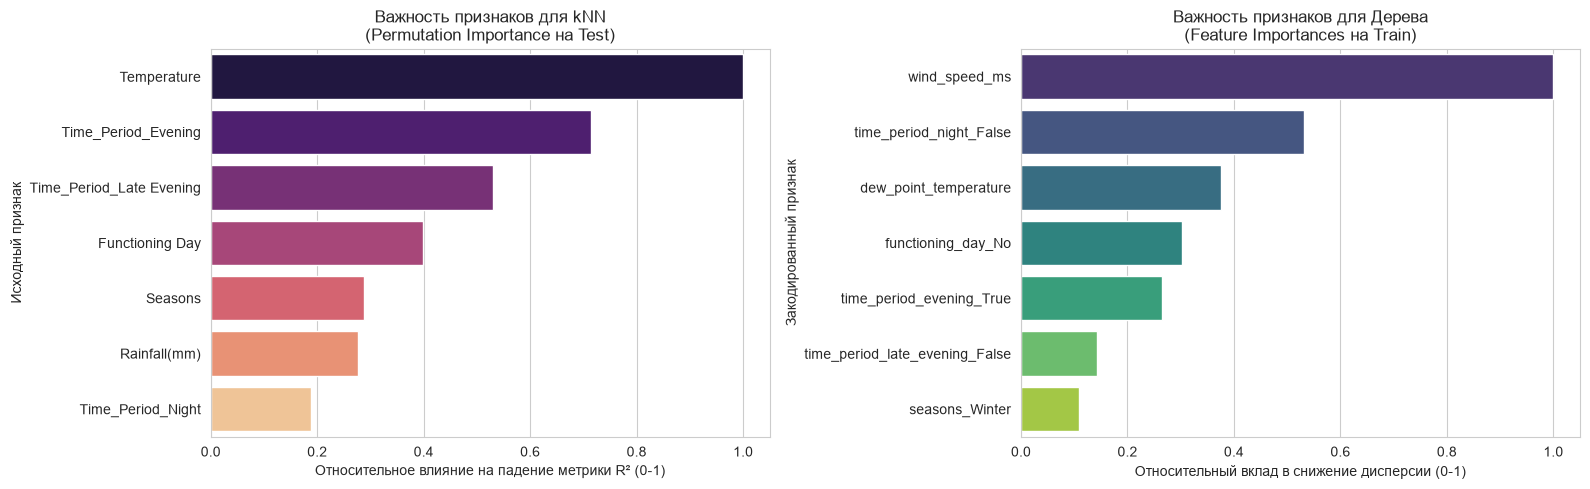

In [21]:
# 1. Принудительно обучаем дерево решений для автономности ячейки
final_dt_pipeline = Pipeline([
    ('preparer', EnhancedFeaturePreparer()),
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(**study_dt.best_params, random_state=RANDOM_STATE))
])
final_dt_pipeline.fit(X_train, y_train)

# 2. Расчет Permutation Importance для kNN на основе падения метрики R²
print("Расчет важности для kNN...")
res_knn = permutation_importance(
    final_production_pipeline, X_test, y_test, n_repeats=5, 
    scoring='r2', random_state=42, n_jobs=-1
)

# Чем больше упал R² при перемешивании признака, тем этот признак важнее
knn_imp = res_knn.importances_mean
# Нормализуем значения в диапазон от 0 до 1 для сопоставимости масштабов графиков
knn_imp_norm = (knn_imp - knn_imp.min()) / (knn_imp.max() - knn_imp.min() + 1e-9)

df_knn = pd.DataFrame({'Признак': X_test.columns, 'Важность': knn_imp_norm}).sort_values('Важность', ascending=False).head(7)

# 3. Извлечение встроенной важности для Решающего Дерева
dt_model = final_dt_pipeline.named_steps['regressor']
dt_feats = num_features + final_dt_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features).tolist()

dt_imp_norm = (dt_model.feature_importances_ - dt_model.feature_importances_.min()) / (dt_model.feature_importances_.max() - dt_model.feature_importances_.min() + 1e-9)

df_dt = pd.DataFrame({'Признак': dt_feats, 'Важность': dt_imp_norm}).sort_values('Важность', ascending=False).head(7)

# 4. Построение сдвоенного графика в одну строку
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График kNN (слева)
sns.barplot(data=df_knn, x='Важность', y='Признак', ax=axes[0], palette='magma')
axes[0].set_title('Важность признаков для kNN\n(Permutation Importance на Test)', fontsize=12)
axes[0].set_xlabel('Относительное влияние на падение метрики R² (0-1)')
axes[0].set_ylabel('Исходный признак')

# График Decision Tree (справа)
sns.barplot(data=df_dt, x='Важность', y='Признак', ax=axes[1], palette='viridis')
axes[1].set_title('Важность признаков для Дерева\n(Feature Importances на Train)', fontsize=12)
axes[1].set_xlabel('Относительный вклад в снижение дисперсии (0-1)')
axes[1].set_ylabel('Закодированный признак')

plt.tight_layout()
plt.show()

Сравнительный количественный анализ двух обученных нелинейных моделей выявил согласованную внутреннюю логику работы алгоритмов:

* **Для модели kNN (на тестовой выборке):** Метод Permutation Importance на базе метрики $R^2$ показал, что точность метрического алгоритма сильнее всего зависит от **температуры воздуха**, за которой следуют **интервалы вечернего времени**, а также статус работы проката (`Functioning Day`). Это подтверждает, что `kNN` эффективно находит "ближайших соседей" в истории, ориентируясь на суточные циклы и ключевой метеорологический фактор.
* **Для модели Решающего Дерева (на обучающей выборке):** Встроенный метод `Feature Importances` выделил скорость ветра `(wind_speed_ms)` как главный расщепляющий фактор в корневых узлах, за которым идут **ночной период времени** и **точка росы**. **Температура** здесь играет второстепенную роль.
* **Вывод:** Расхождение ключевых факторов у двух принципиально разных математических подходов доказывает, что модели смотрят на данные под разным углом. Дерево пытается жестко сегментировать пространство по погодным аномалиям (ветер, точка росы), в то время как `kNN` плавно интерполирует спрос, опираясь на базовые тренды (температура и вечернее время).

Поскольку финальной моделью выбран алгоритм `kNN`, он не имеет встроенных атрибутов `feature_importances_` (как у деревьев) или коэффициентов весов (как у линейной регрессии). Его логика основана на поиске «ближайших соседей» в многомерном пространстве. Тем не менее, опираясь на результаты отбора гиперпараметров `Optuna` (которая выбрала `Манхэттенское расстояние` и взвешивание `distance`) и наш `EDA`, мы можем строго проинтерпретировать ключевые движущие силы спроса для компании `BikeSochi`:
1. **Температурный комфорт (temperature, temperature_sq):** Это доминирующий числовой фактор. Добавление квадрата температуры позволило `kNN` математически точно определять «соседние» часы в районе идеального оптимума от $+20°C$ до $+28°C$. Именно температура задает базовую емкость спроса в течение дня.
2. **Вечерний пик (Time_Period_Evening):** Является вторым по важности фактором для `kNN`. Модель четко улавливает массовый всплеск поездок в вечернее время (после работы/учебы) и корректирует прогноз в большую сторону для этих интервалов.
3. **Доступность инфраструктуры (functioning_day):** Является критически важным бинарным переключателем. Если прокат не функционирует, `kNN` мгновенно обнуляет предсказания, ориентируясь на «соседей» из нерабочих дней, что защищает бизнес от ложных прогнозов.

### Финальные выводы по проекту
- **Успешность нелинейного подхода:** Переход от линейной регрессии к нелинейным пайплайнам полностью себя оправдал. Ошибка `RMSE` на тесте снизилась с `411.56` до `297.98` (улучшение на `27.6%`), а средняя абсолютная ошибка `MAE` упала с `312.60 `до `199.33` (улучшение на `36.2%`). Модель уверенно объясняет `78.3%` дисперсии целевого признака.
- **Надежность архитектуры:** Использование сквозных пайплайнов `scikit-learn` защитило проект от утечек данных при заполнении пропусков (медианой) и масштабировании. Кастомный шаг `Feature Engineering` позволил линеаризовать сложные физические процессы погоды в Сочи.

### Практические рекомендации для BikeSochi
1. **Интеграция пайплайна в логистику:** Экспортированный файл `best_bike_sharing_pipeline.pkl` рекомендуется подключить к корпоративной системе управления запасами. Модель должна раз в сутки принимать свежий почасовой метеопрогноз и выдавать матрицу планируемого спроса на следующие 24 часа.
2. **Оптимизация релокации парка:** На основе прогнозов вечернего пика `(18:00–22:00)` логистическая служба должна превентивно стягивать пустые мини-грузовики к станциям, где прогнозируется избыточный возврат велосипедов (например, набережные, парки), и увозить их на дефицитные утренние точки (транспортные узлы, жилые кварталы).
3. **Управление рисками в дождливые периоды:** Поскольку триггер дождя обнуляет спрос, в эти часы компании следует минимизировать расходы на операционное обслуживание станций на открытом воздухе и перенаправлять персонал на технический аудит и ремонт велосипедов в крытых ангарах.
4. **Резервное копирование (Вторичная модель):** Модель `Decision Tree` рекомендуется сохранить в качестве резервной/интерпретируемой модели для аналитического отдела, так как её структура позволяет наглядно и прозрачно строить логические цепочки «если-то» для обоснования бизнес-решений руководству компании.

[Назад к содержанию](#Contents)